<a href="https://colab.research.google.com/github/bogdanpuscasu123/tema-colab/blob/main/Tema_1_%C3%8EA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔹 Selectează fișierul CSV din calculatorul tău (ex: Coca_Cola_historical_data.csv)...


Saving Coca_Cola_historical_data.csv to Coca_Cola_historical_data (3).csv
✅ Fișier încărcat cu succes: Coca_Cola_historical_data (3).csv
Număr rânduri și coloane: (16066, 8)
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'ticker', 'name'], dtype='object')
                        Date      Open      High       Low     Close   Volume  \
0  1962-01-02 00:00:00-05:00  0.045368  0.046604  0.045368  0.045368   806400   
1  1962-01-03 00:00:00-05:00  0.044695  0.044695  0.043684  0.044358  1574400   
2  1962-01-04 00:00:00-05:00  0.044470  0.045032  0.044470  0.044695   844800   
3  1962-01-05 00:00:00-05:00  0.044695  0.045256  0.043572  0.043684  1420800   
4  1962-01-08 00:00:00-05:00  0.043347  0.043347  0.042392  0.043235  2035200   

  ticker                                        name  
0     KO  The Coca-Cola Company (KO) Historical Data  
1     KO  The Coca-Cola Company (KO) Historical Data  
2     KO  The Coca-Cola Company (KO) Historical Data  
3     KO  The Coca-Cola Com

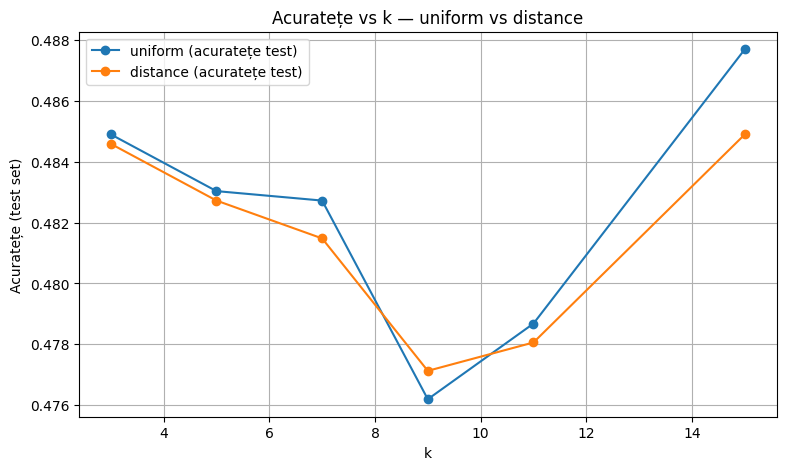


--- Raport clasificare baseline ---
              precision    recall  f1-score   support

           0       0.47      0.83      0.60      1529
           1       0.49      0.15      0.23      1684

    accuracy                           0.47      3213
   macro avg       0.48      0.49      0.41      3213
weighted avg       0.48      0.47      0.41      3213


--- Raport clasificare model optimizat ---
              precision    recall  f1-score   support

           0       0.48      0.79      0.59      1529
           1       0.52      0.21      0.30      1684

    accuracy                           0.48      3213
   macro avg       0.50      0.50      0.44      3213
weighted avg       0.50      0.48      0.44      3213


Rezumat salvat în: /content/knn_comparison_summary.csv
Detalii CV salvate în: /content/knn_ts_cv_results.csv


In [4]:
# -------------------------
# k-NN: determinarea valorii optime pentru k și comparație
# Dataset: Coca_Cola_historical_data.csv
# Limbaj: Python (scikit-learn)
# Rulare: Google Colab
# -------------------------

# --- 0. Importuri necesare ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# -------------------------
# 1. Încărcare date
# -------------------------
# Metoda recomandată în Colab: încărcarea manuală a fișierului CSV
from google.colab import files

print("🔹 Selectează fișierul CSV din calculatorul tău (ex: Coca_Cola_historical_data.csv)...")
uploaded = files.upload()

CSV_PATH = list(uploaded.keys())[0]
print("✅ Fișier încărcat cu succes:", CSV_PATH)

# Citire fișier și sortare după dată
df = pd.read_csv(CSV_PATH, parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Verificare rapidă
print("Număr rânduri și coloane:", df.shape)
print(df.columns)
print(df.head())

# -------------------------
# 2. Crearea caracteristicilor (feature engineering)
# -------------------------
df['Close'] = df['Close'].astype(float)
df['return_1'] = df['Close'].pct_change(1)  # randament zi curentă față de ziua precedentă
df['return_2'] = df['Close'].pct_change(2)  # randament pe 2 zile
df['ma_5'] = df['Close'].rolling(5).mean()  # medie mobilă 5 zile
df['std_5'] = df['Close'].rolling(5).std()  # deviația standard 5 zile (volatilitate)
df['vol_change'] = df['Volume'].pct_change(1)  # schimbarea volumului între zile

# Etichetă: 1 dacă mâine prețul de închidere este mai mare decât azi, altfel 0
df['Close_next'] = df['Close'].shift(-1)
df['label'] = (df['Close_next'] > df['Close']).astype(int)

# Eliminare rânduri cu valori NaN generate de rolling/shift
df_model = df.dropna(subset=['return_1','ma_5','std_5','vol_change','label']).copy()

features = ['return_1','return_2','ma_5','std_5','vol_change']
X = df_model[features].values
y = df_model['label'].values

print("Număr de mostre după curățare:", X.shape[0])

# -------------------------
# 3. Împărțire temporală (80% train, 20% test)
# -------------------------
n = len(X)
train_size = int(0.8 * n)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Standardizare (important pentru k-NN)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# -------------------------
# 4. Baseline: k = sqrt(N_train)
# -------------------------
k_heur = int(np.sqrt(X_train_s.shape[0]))
if k_heur % 2 == 0:
    k_heur += 1

baseline = KNeighborsClassifier(n_neighbors=k_heur, weights='uniform', metric='euclidean')
t0 = time.time()
baseline.fit(X_train_s, y_train)
t1 = time.time()
train_time_baseline = t1 - t0

t0 = time.time()
y_pred_baseline = baseline.predict(X_test_s)
t1 = time.time()
pred_time_baseline = t1 - t0

def compute_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'confusion': confusion_matrix(y_true, y_pred)
    }

metrics_baseline = compute_metrics(y_test, y_pred_baseline)
metrics_baseline.update({'k': k_heur, 'train_time_s': train_time_baseline, 'pred_time_s': pred_time_baseline})

print(f"\nMetrici baseline (k={k_heur}, vot uniform):")
for k,v in metrics_baseline.items():
    if k != 'confusion':
        print(f"  {k}: {v}")
print("Matrice de confuzie:\n", metrics_baseline['confusion'])

# -------------------------
# 5. TimeSeriesSplit CV pentru alegerea k optim
# -------------------------
ks_grid = [3,5,7,9,11,15]
tscv = TimeSeriesSplit(n_splits=3)

cv_results = []
for k in ks_grid:
    accs = []
    for train_idx, val_idx in tscv.split(X_train_s):
        Xtr, Xval = X_train_s[train_idx], X_train_s[val_idx]
        ytr, yval = y_train[train_idx], y_train[val_idx]
        clf = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
        clf.fit(Xtr, ytr)
        yv = clf.predict(Xval)
        accs.append(accuracy_score(yval, yv))
    cv_results.append({'k': k, 'mean_cv_acc': np.mean(accs)})

cv_df = pd.DataFrame(cv_results).sort_values('mean_cv_acc', ascending=False).reset_index(drop=True)
print("\nRezultate CV (TimeSeriesSplit) sortate după acuratețe medie:")
print(cv_df)

best_k = int(cv_df.loc[0,'k'])
best_model = KNeighborsClassifier(n_neighbors=best_k, weights='distance', metric='euclidean')

t0 = time.time()
best_model.fit(X_train_s, y_train)
t1 = time.time()
train_time_best = t1 - t0

t0 = time.time()
y_pred_best = best_model.predict(X_test_s)
t1 = time.time()
pred_time_best = t1 - t0

metrics_best = compute_metrics(y_test, y_pred_best)
metrics_best.update({'k': best_k, 'train_time_s': train_time_best, 'pred_time_s': pred_time_best, 'cv_mean_acc': float(cv_df.loc[0,'mean_cv_acc'])})

print(f"\nMetrici model optimizat (TimeSeriesSplit + distance), k={best_k}:")
for k,v in metrics_best.items():
    if k != 'confusion':
        print(f"  {k}: {v}")
print("Matrice de confuzie:\n", metrics_best['confusion'])

# -------------------------
# 6. Curbe și comparații
# -------------------------
acc_u = []
acc_d = []
for k in ks_grid:
    cu = KNeighborsClassifier(n_neighbors=k, weights='uniform').fit(X_train_s, y_train)
    cd = KNeighborsClassifier(n_neighbors=k, weights='distance').fit(X_train_s, y_train)
    acc_u.append(accuracy_score(y_test, cu.predict(X_test_s)))
    acc_d.append(accuracy_score(y_test, cd.predict(X_test_s)))

plt.figure(figsize=(9,5))
plt.plot(ks_grid, acc_u, marker='o', label='uniform (acuratețe test)')
plt.plot(ks_grid, acc_d, marker='o', label='distance (acuratețe test)')
plt.xlabel('k')
plt.ylabel('Acuratețe (test set)')
plt.title('Acuratețe vs k — uniform vs distance')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- Raport clasificare baseline ---")
print(classification_report(y_test, y_pred_baseline, zero_division=0))
print("\n--- Raport clasificare model optimizat ---")
print(classification_report(y_test, y_pred_best, zero_division=0))

# -------------------------
# 7. Salvare rezultate
# -------------------------
summary = pd.DataFrame([
    {
        'method': 'baseline (heuristic)',
        'k': metrics_baseline['k'],
        'weights': 'uniform',
        'train_time_s': metrics_baseline['train_time_s'],
        'pred_time_s': metrics_baseline['pred_time_s'],
        'accuracy': metrics_baseline['accuracy'],
        'precision': metrics_baseline['precision'],
        'recall': metrics_baseline['recall'],
        'f1': metrics_baseline['f1']
    },
    {
        'method': 'tscv + distance (selectat)',
        'k': metrics_best['k'],
        'weights': 'distance',
        'train_time_s': metrics_best['train_time_s'],
        'pred_time_s': metrics_best['pred_time_s'],
        'cv_mean_acc': metrics_best.get('cv_mean_acc', np.nan),
        'accuracy': metrics_best['accuracy'],
        'precision': metrics_best['precision'],
        'recall': metrics_best['recall'],
        'f1': metrics_best['f1']
    }
])

summary_path = '/content/knn_comparison_summary.csv'
cv_df_path = '/content/knn_ts_cv_results.csv'
summary.to_csv(summary_path, index=False)
cv_df.to_csv(cv_df_path, index=False)
print("\nRezumat salvat în:", summary_path)
print("Detalii CV salvate în:", cv_df_path)
